In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# One Run, large corner

In [15]:
filename = '0mm_splined_134700_chains.csv'
truth_filename = 'splined_134700_truth.csv'

data0 = pd.read_csv(filename)
keys = ['beta', 'lambda', 'chi1', 'chi2', 'Deltat', 'phi', 'dist', 'psi', 'inc', 'Mchirp', 'q']
df0 = pd.DataFrame(data0, columns = keys)

locations0 = df0[['beta','lambda']].copy()
masses0 = df0[['Mchirp', 'q']].copy()
spins0 = df0[['chi1', 'chi2']].copy()

truth = pd.read_csv(truth_filename)
truths = pd.DataFrame(truth, columns = ['truths'])
print(truths['truths'])

0    -3.030044e-01
1     1.292518e+00
2     2.686319e-01
3    -4.215110e-01
4     1.152694e+07
5    -1.921396e+00
6     1.347010e+05
7     1.291223e+00
8     2.251790e+00
9     7.724629e+05
10    2.160504e+00
Name: truths, dtype: float64


file truth 22295 1.34798356e+03

In [16]:
burn = 0

In [17]:

truth_values = list(truth['truths'])
print(list(truth['truths']))

[-0.3030044229417423, 1.292518386104852, 0.2686319092266767, -0.4215109787709388, 11526944.921879262, -1.921395767588228, 134700.983559, 1.2912226019238924, 2.2517895222056112, 772462.8571528315, 2.160504152820206]


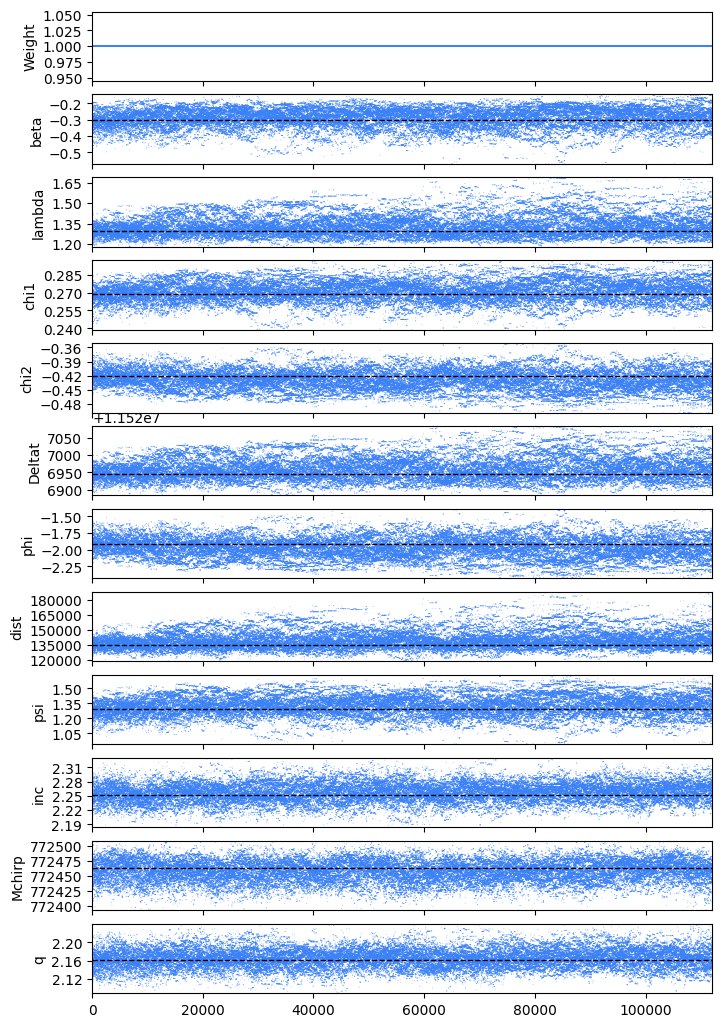

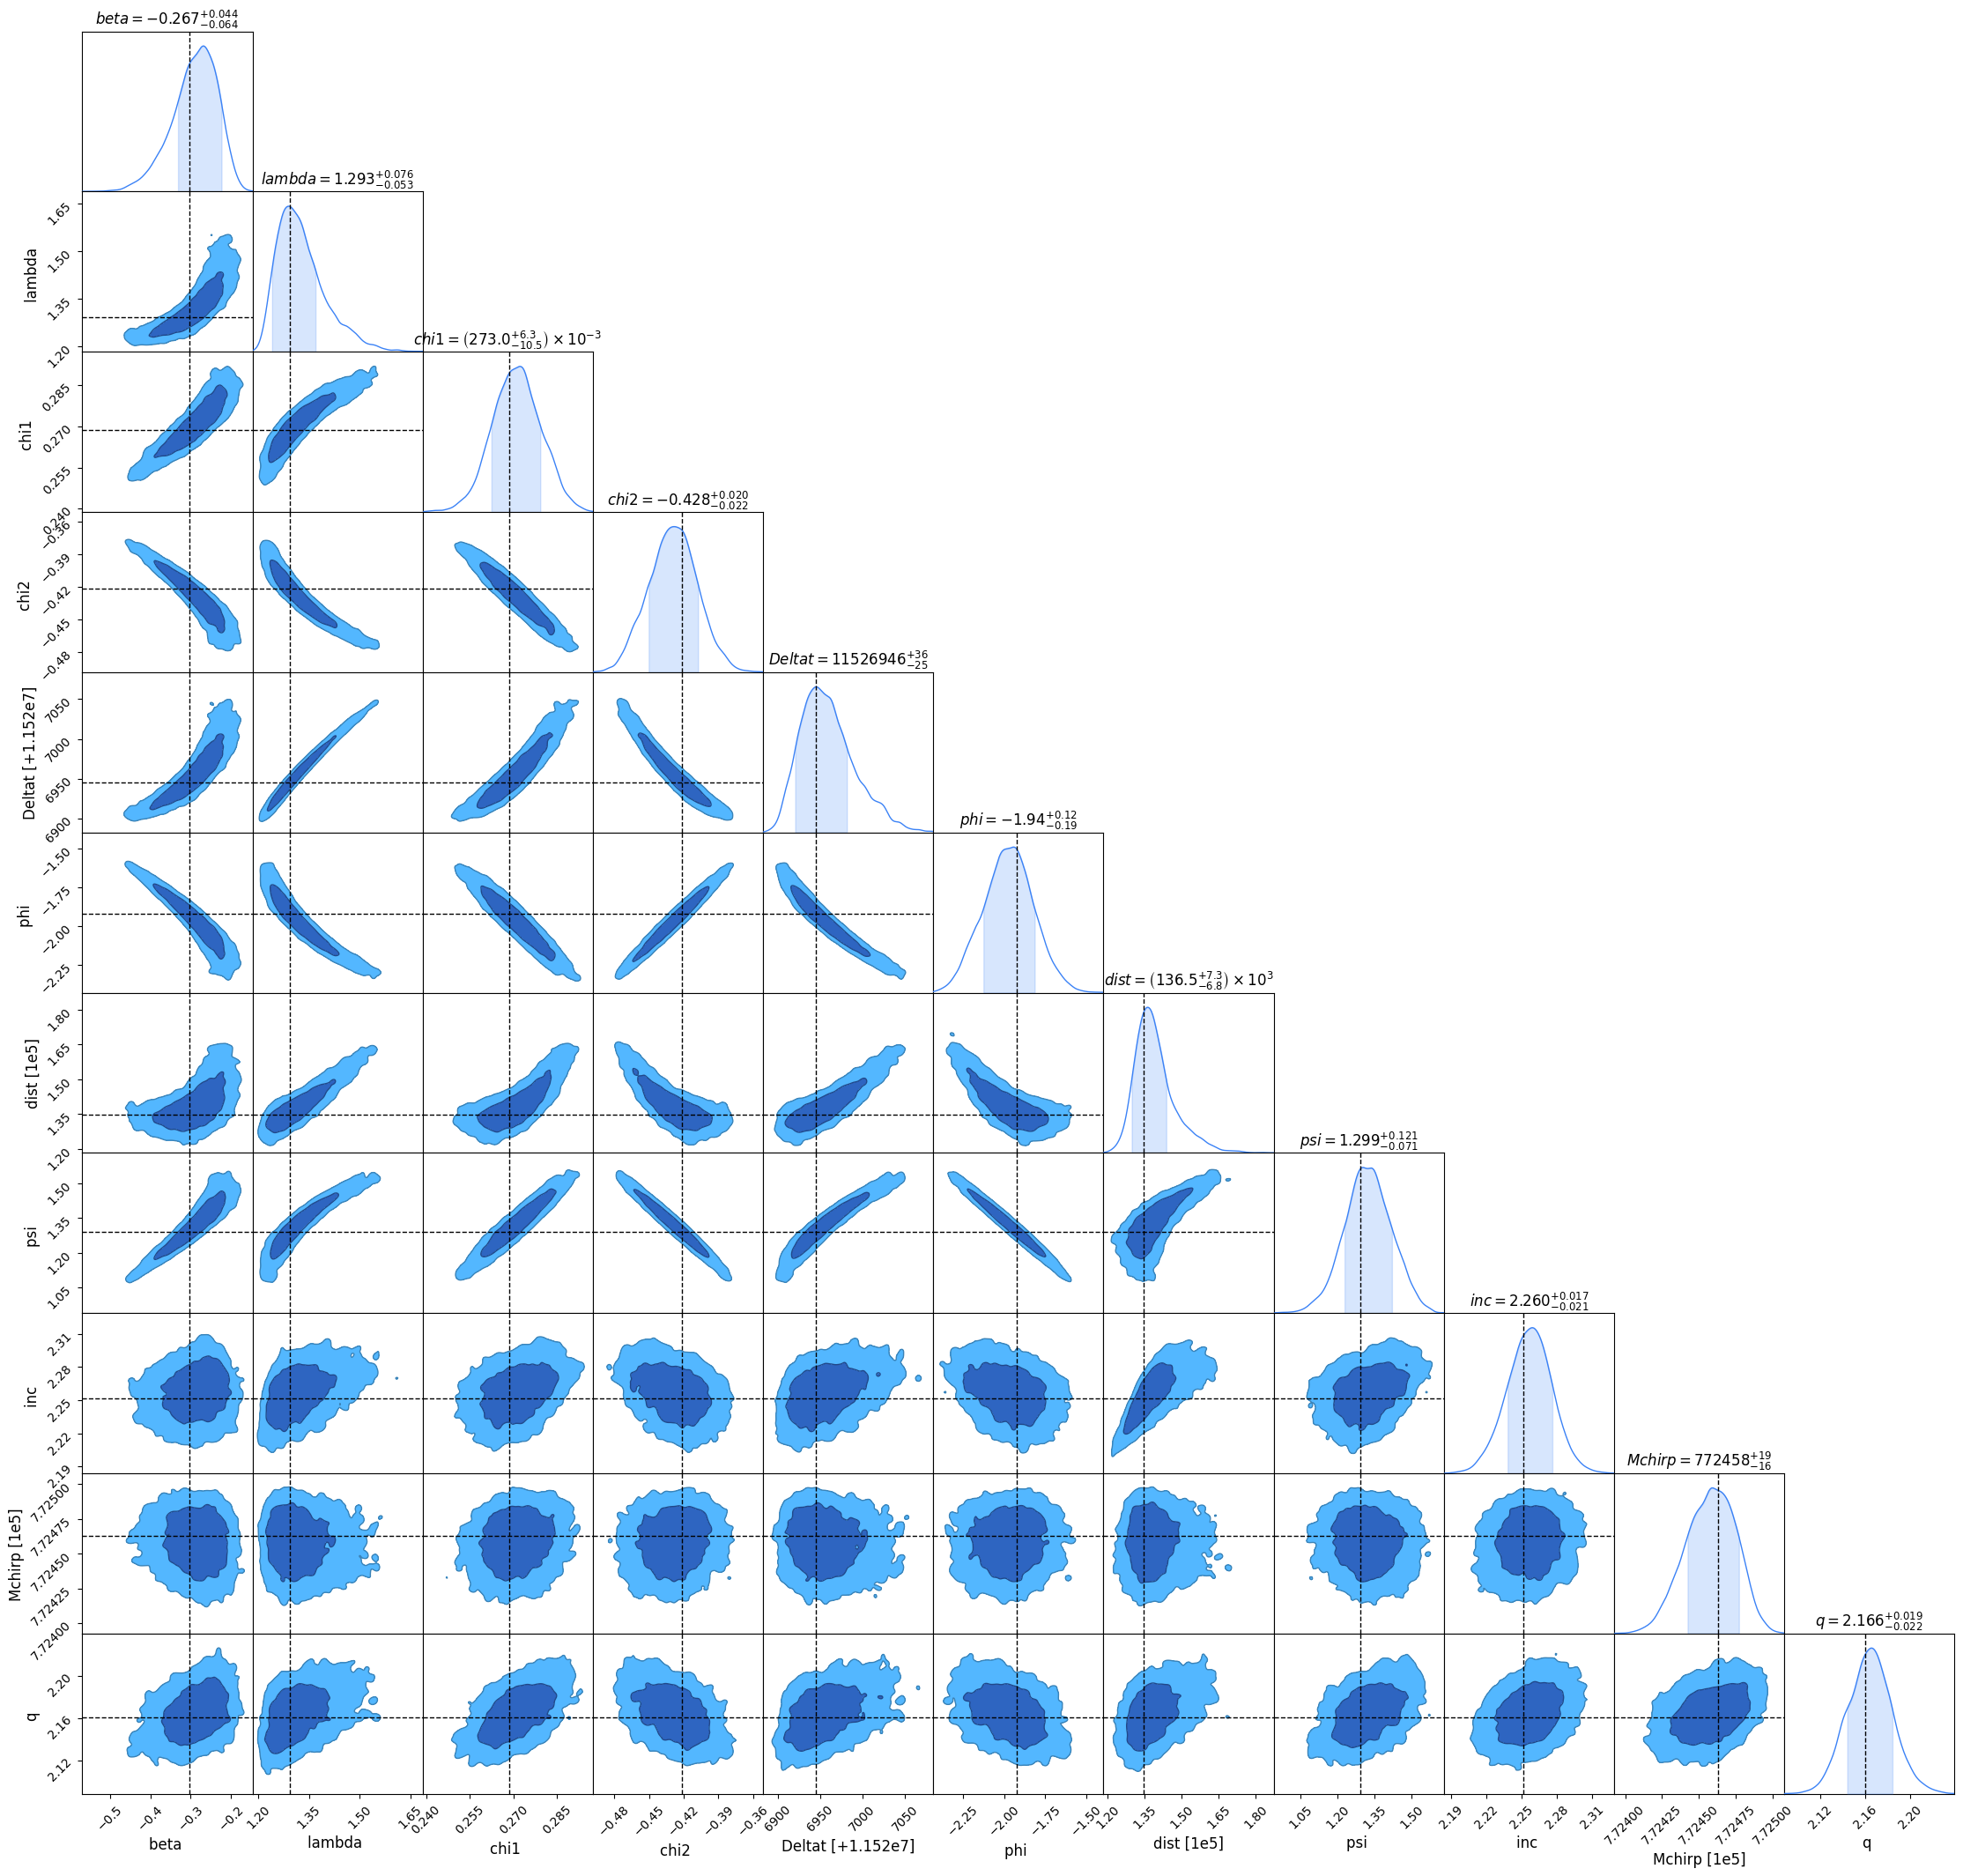

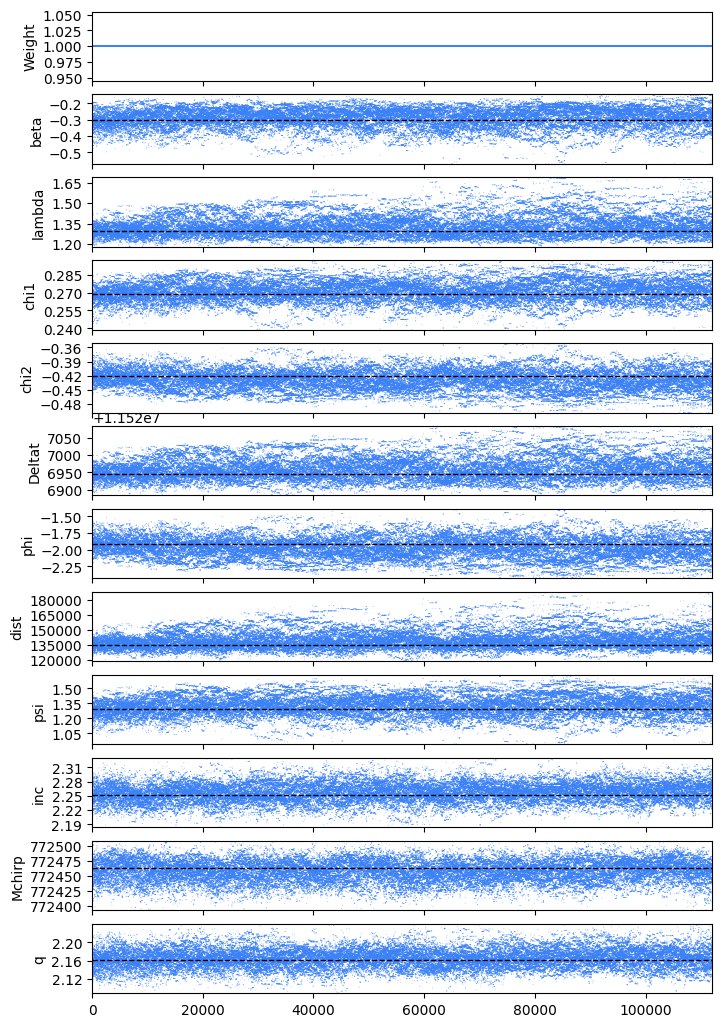

In [18]:
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
c = ChainConsumer()
burn = 20000
c.add_chain(Chain(samples=data0[burn:], name="standard", color="blue"))
#c.add_chain(Chain(samples=data1[burn:], name="standard", color="purple"))
c.add_truth(Truth(location={k:v for (k,v) in zip(keys,truth_values)}))

c.plotter.plot()
c.plotter.plot_walks()

# small plots

0    -3.030044e-01
1     1.292518e+00
2     2.686319e-01
3    -4.215110e-01
4     1.152694e+07
5    -1.921396e+00
6     1.347010e+05
7     1.291223e+00
8     2.251790e+00
9     7.724629e+05
10    2.160504e+00
Name: truths, dtype: float64


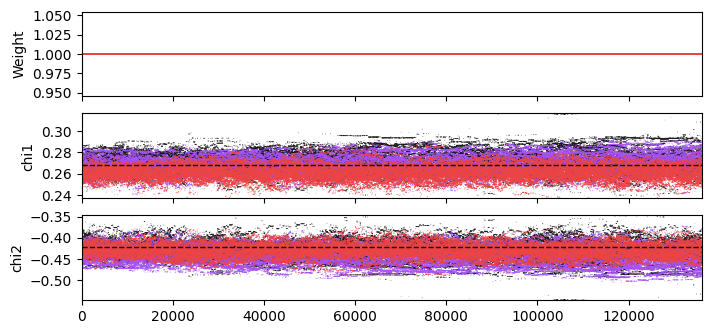

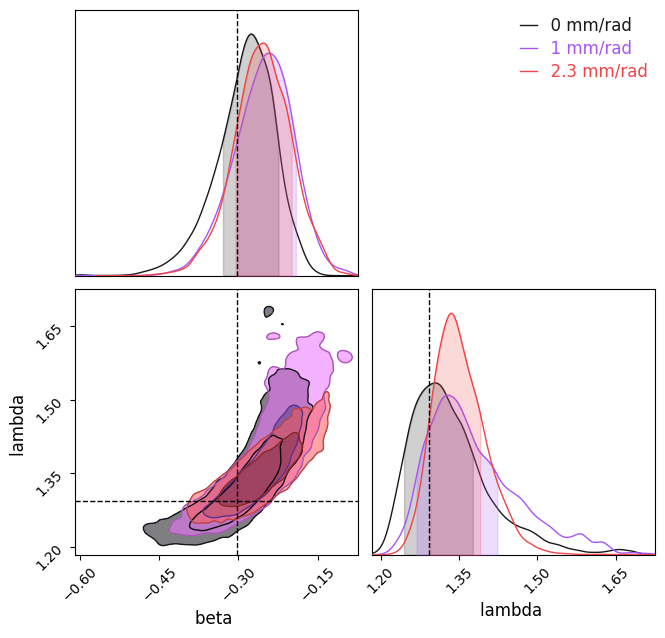

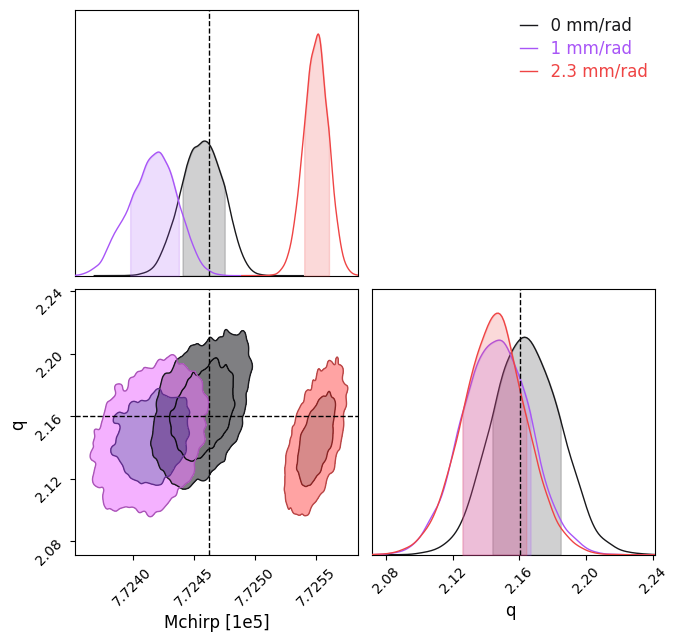

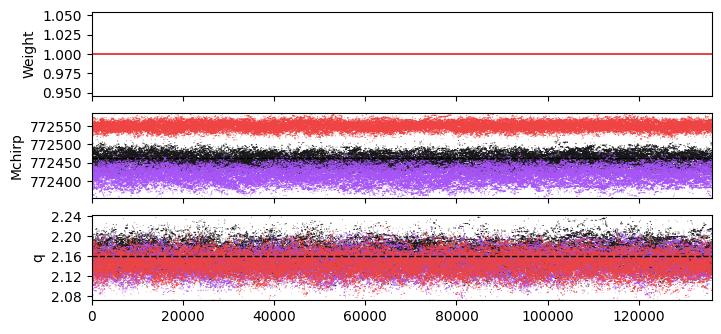

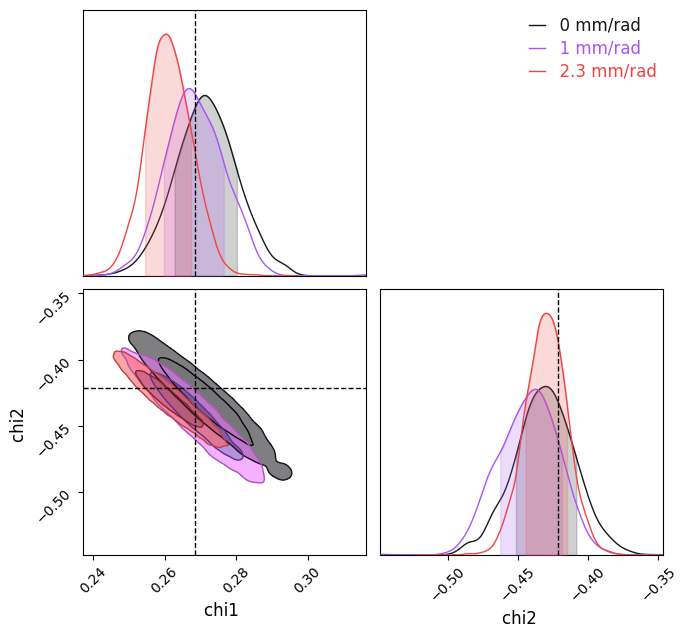

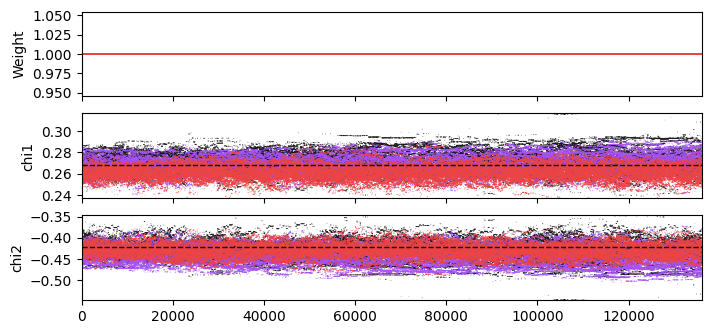

In [8]:
import pandas as pd

filename0 = "0mm_134700_fixed_noise_chains.csv"
filename1 = "1mm_134700_fixed_noise_chains.csv"
filename2 = "2mm_134700_fixed_noise_chains.csv"

truth_filename = 'splined_134700_truth.csv'


truth = pd.read_csv(truth_filename)
truths = pd.DataFrame(truth, columns = ['truths'])
print(truths['truths'])

data0 = pd.read_csv(filename0)
keys = ['beta', 'lambda', 'chi1', 'chi2', 'Deltat', 'phi', 'dist', 'psi', 'inc', 'Mchirp', 'q']
df0 = pd.DataFrame(data0, columns = keys)

locations0 = df0[['beta','lambda']].copy()
masses0 = df0[['Mchirp', 'q']].copy()
spins0 = df0[['chi1', 'chi2']].copy()

data1 = pd.read_csv(filename1)
df1 = pd.DataFrame(data1, columns = keys)

locations1 = df1[['beta','lambda']].copy()
masses1 = df1[['Mchirp', 'q']].copy()
spins1 = df1[['chi1', 'chi2']].copy()

data2 = pd.read_csv(filename2)
df2 = pd.DataFrame(data2, columns = keys)

locations2 = df2[['beta','lambda']].copy()
masses2 = df2[['Mchirp', 'q']].copy()
spins2 = df2[['chi1', 'chi2']].copy()


burn = 40000

#sky locs
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
a = ChainConsumer()

a.add_chain(Chain(samples=locations0[burn:], name="0 mm/rad", color="black"))
a.add_chain(Chain(samples=locations1[burn:], name="1 mm/rad", color="purple"))
a.add_chain(Chain(samples=locations2[burn:], name="2.3 mm/rad", color="red"))
a.add_truth(Truth(location={'beta': truths['truths'][0], 'lambda': truths['truths'][1]}))

a.plotter.plot(filename = 'Sky_location_corner.png')

#masses
b = ChainConsumer()

b.add_chain(Chain(samples=masses0[burn:], name="0 mm/rad", color="black"))
b.add_chain(Chain(samples=masses1[burn:], name="1 mm/rad", color="purple"))
b.add_chain(Chain(samples=masses2[burn:], name="2.3 mm/rad", color="red"))
b.add_truth(Truth(location={'Mchirp': truths['truths'][9], 'q': truths['truths'][10]}))

b.plotter.plot(filename = 'Masses_corner.png')
b.plotter.plot_walks()

#spins
c = ChainConsumer()

c.add_chain(Chain(samples=spins0[burn:], name="0 mm/rad", color="black"))
c.add_chain(Chain(samples=spins1[burn:], name="1 mm/rad", color="purple"))
c.add_chain(Chain(samples=spins2[burn:], name="2.3 mm/rad", color="red"))
c.add_truth(Truth(location={'chi1': truths['truths'][2], 'chi2': truths['truths'][3]}))

c.plotter.plot(filename = 'Spins_corner.png')
c.plotter.plot_walks()


In [182]:
import LISA_TTL_Functions as foc

# PSDs of sources and noise

In [217]:
pMBHB_0 = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932, #original 1323277.47932
 'Mass2': 612485.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559, #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

In [218]:
pMBHB_1 = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 13232770.47932, #original 1323277.47932
 'Mass2': 6124850.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559 , #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

In [219]:
pMBHB_2 = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 132327.747932, #original 1323277.47932
 'Mass2': 61248.55060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 134700.983559, #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

In [220]:
m1 = pMBHB_2['Mass1']
m2 = pMBHB_2['Mass2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6
print(q,Mc)

2.160504152820206 77246.28571528316


In [221]:
t_min = 0
t_max = pMBHB_0["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

In [222]:
A_full, E_full, Npsd, src, src0, freq, keys = foc.Fulls(pMBHB_0)
A_full2, E_full2, Npsd2, src2, src02, freq2, keys2 = foc.Fulls(pMBHB_1)
A_full3, E_full3, Npsd3, src3, src03, freq3, keys3 = foc.Fulls(pMBHB_2)

In [223]:
print(len(freq), len(freq2), len(freq3))
print(len(A_full), len(A_full2), len(A_full3))

265 228 423
265 228 423


In [224]:
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10
freq_ttl = np.logspace(-5, 0, num = 300)
fstar = 0.0190854 #c/L/(2*np.pi)
psd1 = ((6e-11*(np.sin(2*freq_ttl/fstar)**2) + 1e-12)/2.5e9)**2/(df*4)
psd2 = ((2e-10*(np.sin(2*freq_ttl/fstar)**2) + 1e-12)/2.5e9)**2/(df*4)

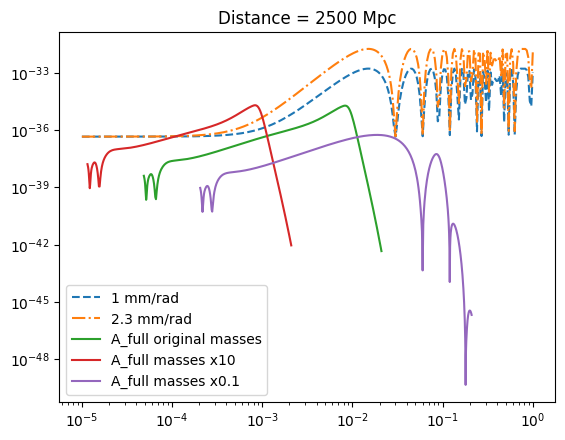

In [225]:
plt.loglog(freq_ttl, psd1,'--', label = '1 mm/rad')
plt.loglog(freq_ttl, psd2,'-.', label = '2.3 mm/rad')
plt.loglog(freq, np.abs(A_full)**2, label = 'A_full original masses')
plt.loglog(freq2, np.abs(A_full2)**2, label = 'A_full masses x10')
plt.loglog(freq3, np.abs(A_full3)**2, label = 'A_full masses x0.1')

plt.title('Distance = 2500 Mpc')
plt.legend()

In [109]:
#generate noise psd for 1mm
psd_sqrt = (6e-11*(np.sin(2*freq3/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
psd_sqrt2 = (2e-10*(np.sin(2*freq3/fstar)**2) + 1e-12)/2.5e9 #2.5e9 is armlength
#1mm eyeball -> 6e-11
#2mm eyeball -> 2e-10
#10mm eyeball -> 8e-10
psd = ((2e-10*(np.sin(2*freq_ttl/fstar)**2) + 1e-12)/2.5e9)**2/(df*4)

#Add noise function
def randc(r):
    return r/np.sqrt(2)*(np.random.randn(*r.shape) + 1j*np.random.randn(*r.shape))

#create noise fft
noise_fft = randc(psd_sqrt)
noise_fft2 = randc(psd_sqrt2)


In [110]:
Afull = A_full3+ noise_fft/np.sqrt(df*4)
Afull2 = A_full3+ noise_fft2/np.sqrt(df*4)

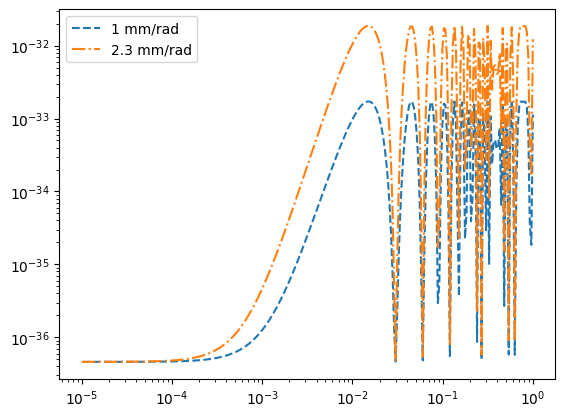

In [111]:
#plt.loglog(freq3, np.abs(A_full3)**2, label = 'noiseless')
#plt.loglog(freq3, np.abs(Afull2)**2, label = '2.3 mm/rad source')
#plt.loglog(freq3, np.abs(Afull)**2, label = '1 mm/rad source')
plt.loglog(freq_ttl, psd1,'--', label = '1 mm/rad')
plt.loglog(freq_ttl, psd2,'-.', label = '2.3 mm/rad')
plt.legend()